PROCESO LIGHTGBM CON BÚSQUEDA DE CARACTERÍSTICAS Y AJUSTE DE HIPERPARÁMETROS
CON EVALUACIÓN EN TEST PARA EVITAR SOBREAJUSTE

Cargando datos de entrenamiento desde: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_90_10.xlsx
Datos de entrenamiento: 243 muestras, 115 características
Iniciando ingeniería de atributos optimizada...
Escalando características...
Características después de ingeniería: 140

BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS (LightGBM)

Probando con 10 características...
  MAE: 6.1521, R²: 0.8128, RMSE: 8.6845
  MAE en picos (>P90): 13.8992

Probando con 15 características...
  MAE: 6.0221, R²: 0.8002, RMSE: 8.9720
  MAE en picos (>P90): 10.1547

Probando con 20 características...
  MAE: 6.0123, R²: 0.8077, RMSE: 8.8029
  MAE en picos (>P90): 11.0518

Probando con 25 características...
  MAE: 5.7572, R²: 0.8198, RMSE: 8.5206
  MAE en picos (>P90): 10.3659

Probando con 3

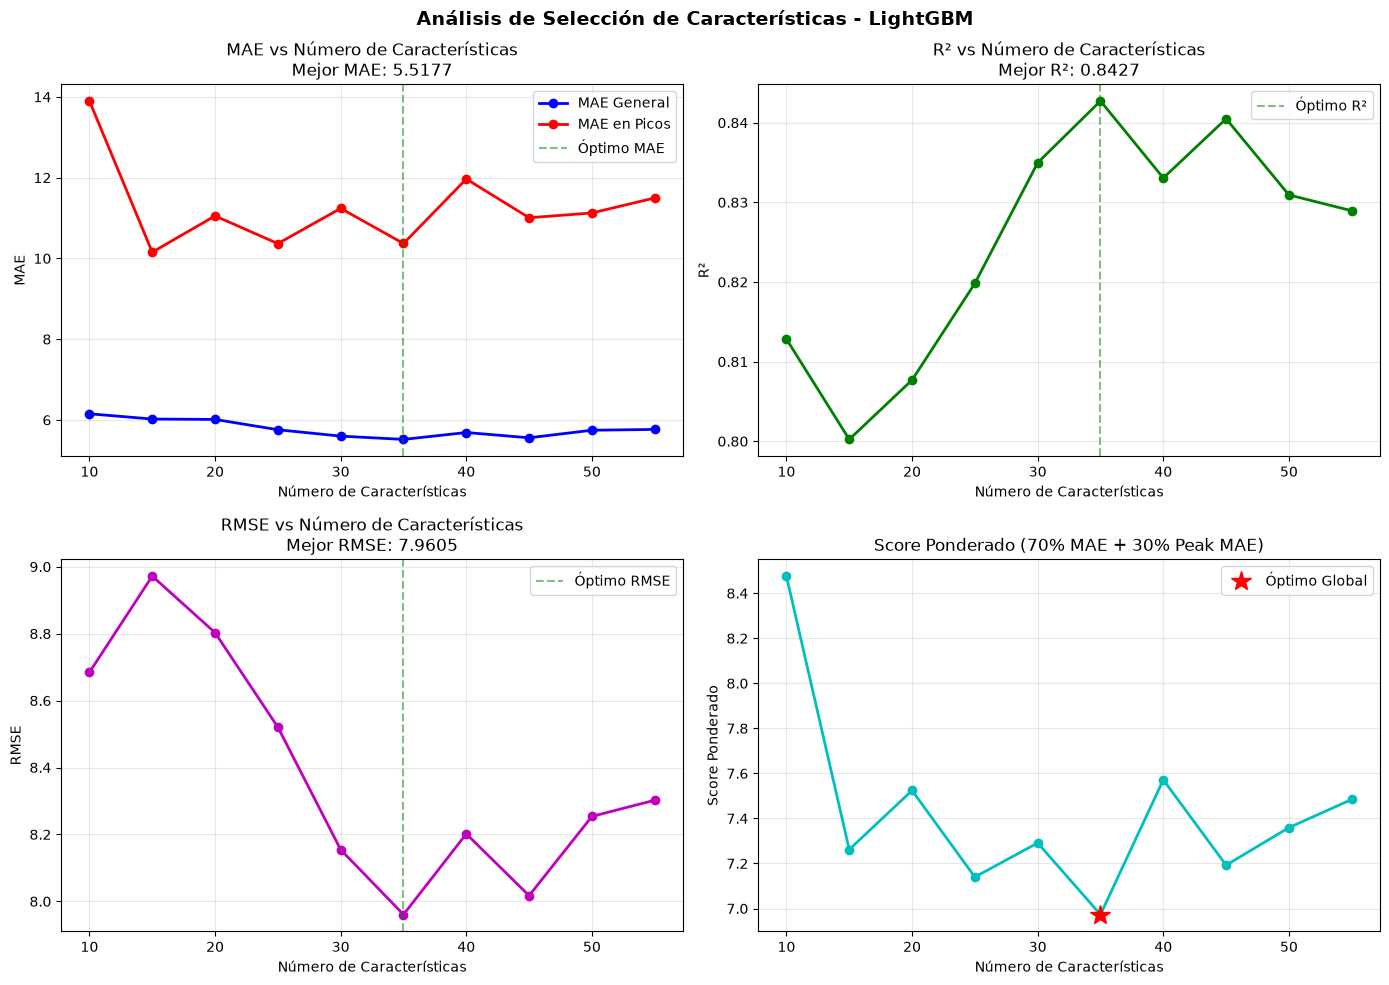

✅ Gráfico de ajuste de hiperparámetros guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\hyperparameter_tuning_results_lightgbm.png


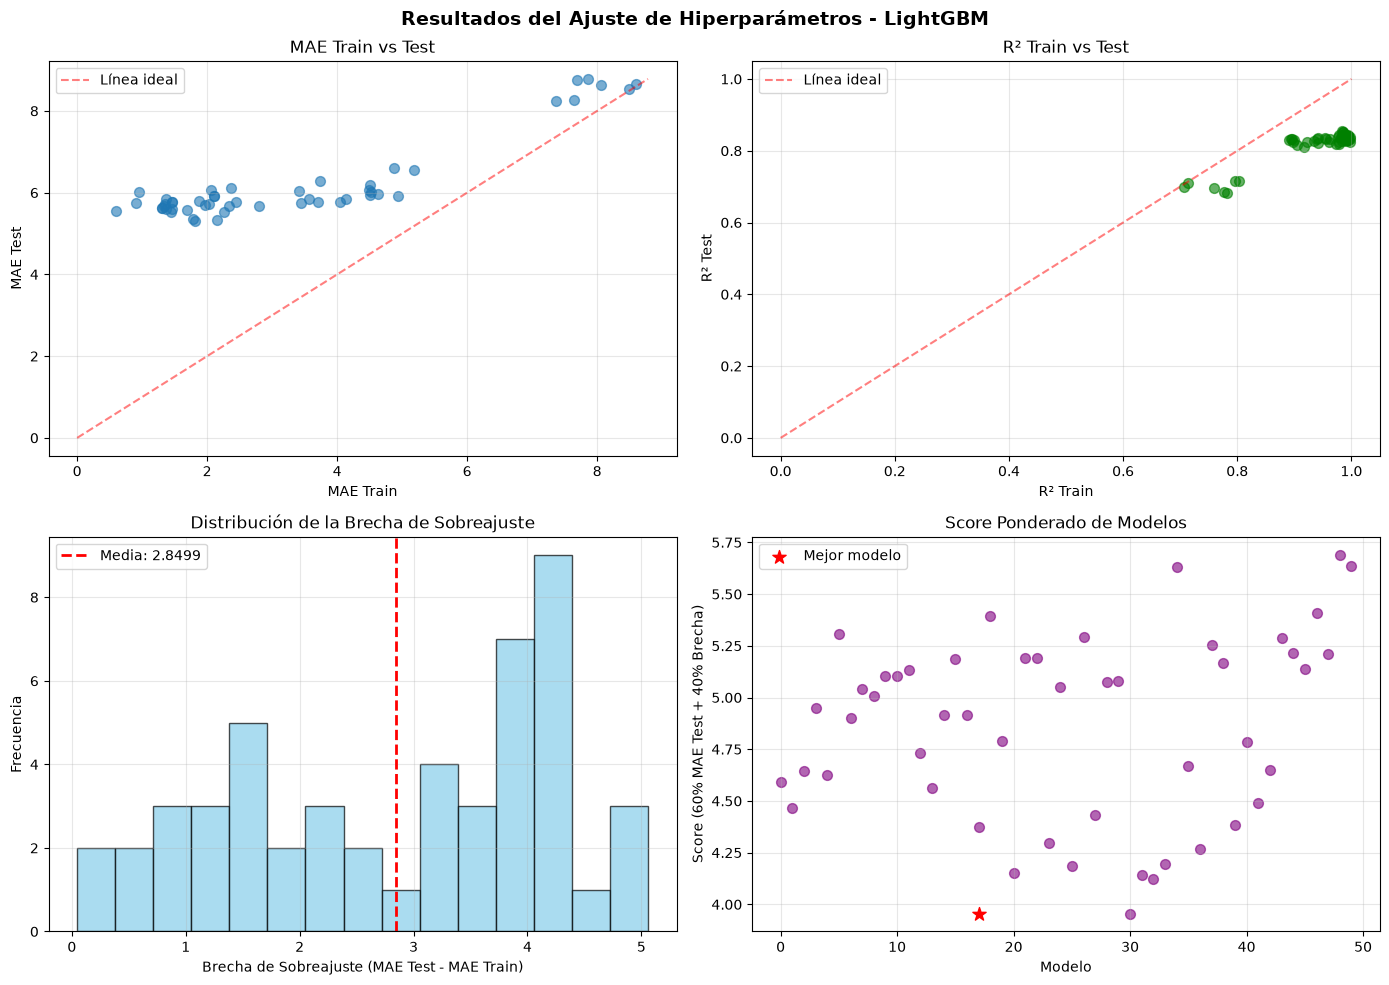

✅ Análisis de picos guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\peak_analysis_lightgbm.png


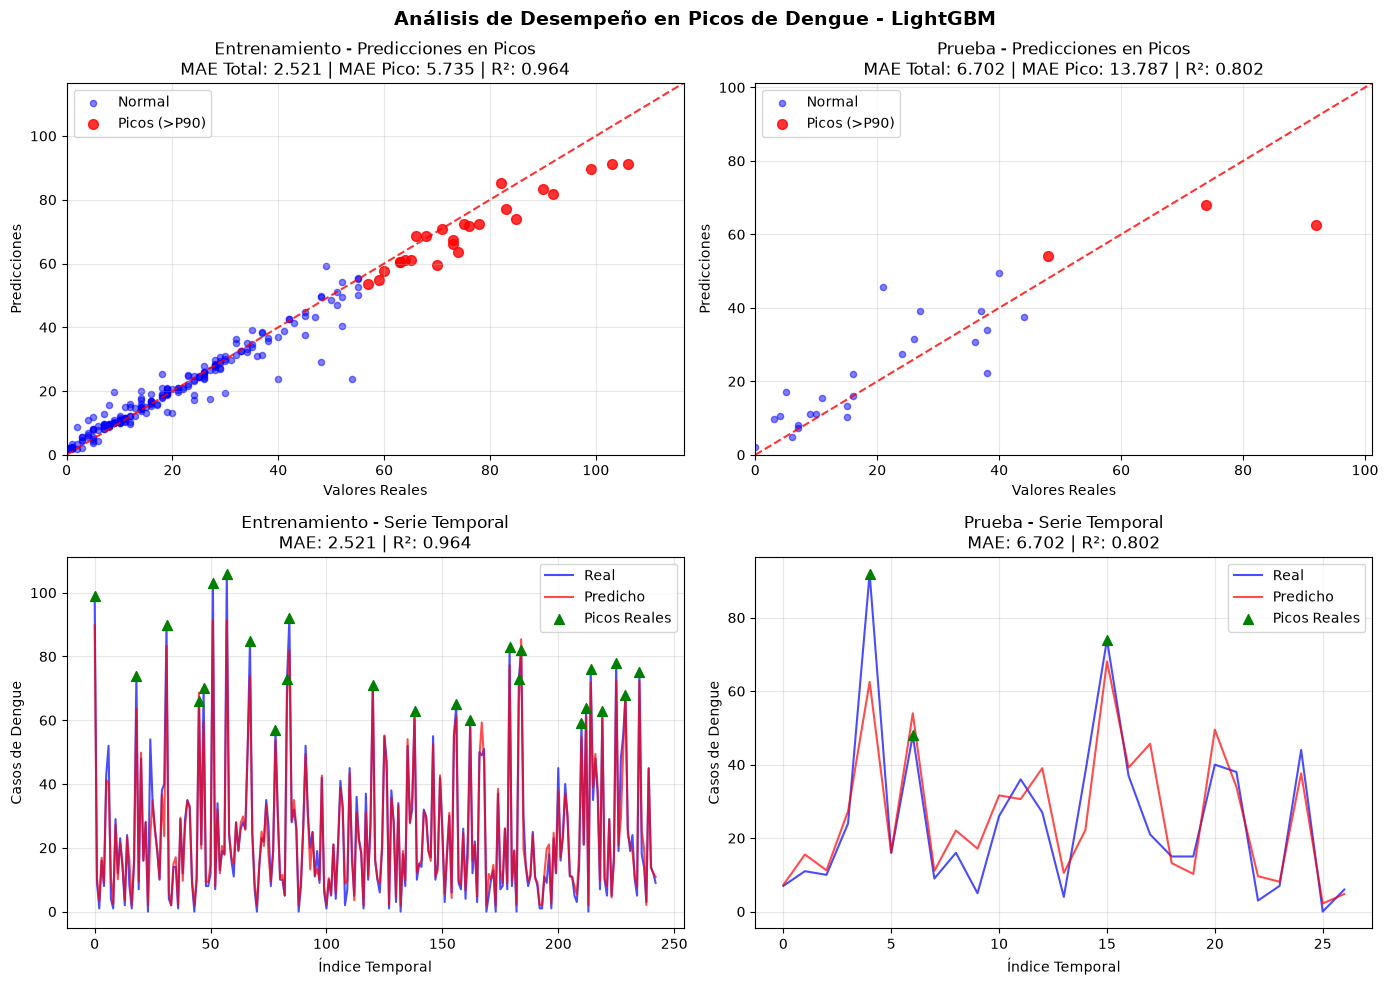

✅ Comparación guardada en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\performance_comparison_lightgbm.png


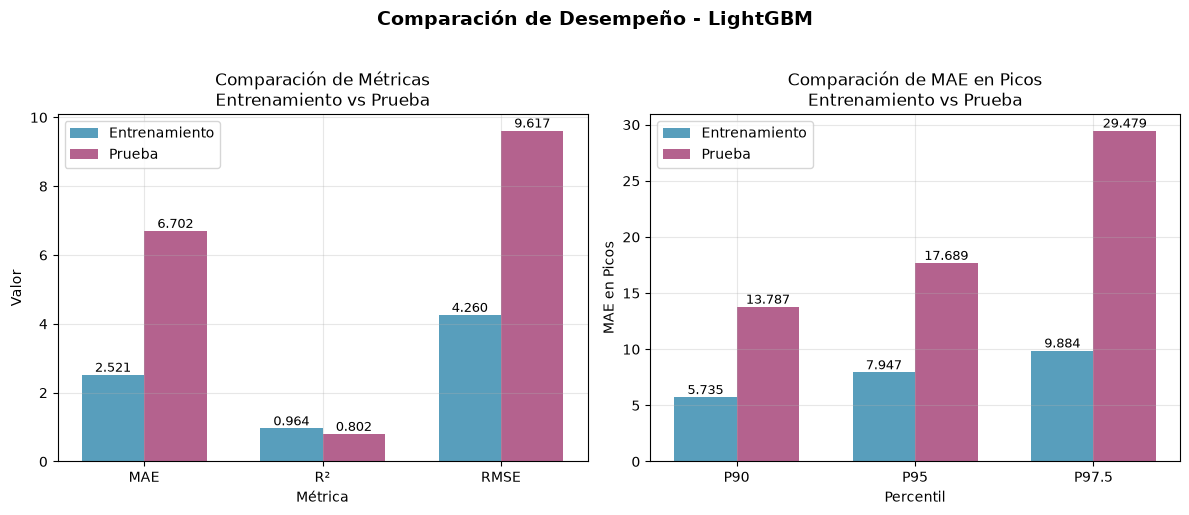

✅ Script de despliegue generado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\modelo_despliegue_lightgbm.py

PROCESO LIGHTGBM COMPLETADO EXITOSAMENTE
Resultados guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\resultados_lightgbm_optimizados.xlsx
Análisis de selección: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\feature_selection_analysis_lightgbm.png
Análisis de picos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\peak_analysis_lightgbm.png
Comparación de desempeño: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi\performance_com

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
import warnings
import os
from datetime import datetime
import json
import pickle
from scipy.stats import uniform, randint
warnings.filterwarnings('ignore')

class DengueFeatureEngineeringOptimizedLGBM:
    def __init__(self, n_features_to_select=25):
        """
        Clase optimizada para ingeniería de atributos y reducción de overfitting
        usando LightGBM
        """
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.rfe = None
        self.selected_features = None
        self.feature_names = None
        self.lgbm_model = None
        self.numeric_columns = None
        self.feature_importance_df = None
        self.best_params = None
        self.peak_mae = None
        self.X_augmented_columns = None
        self.best_metrics = None
        self.all_features_importance = None
        self.cv_results = None
        self.train_val_metrics = None

    def create_interaction_features(self, X):
        """Crea características de interacción seleccionadas estratégicamente"""
        interaction_data = pd.DataFrame(index=X.index)

        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]

        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]

        return interaction_data

    def create_polynomial_features(self, X):
        """Crea características polinomiales solo para variables clave"""
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)

        for var in important_vars:
            if var in X.columns:
                poly_features[f'{var}_squared'] = X[var] ** 2

        return poly_features

    def create_lag_aggregates(self, X):
        """Crea agregados de rezagos con regularización"""
        lag_aggs = pd.DataFrame(index=X.index)

        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel', 'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns if col.startswith(f'{base_var}_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[f'{base_var}_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[f'{base_var}_lag_std'] = lag_data.std(axis=1)

        dengue_lag_cols = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)

        return lag_aggs

    def create_rolling_features(self, X):
        """Crea características de tendencia temporal simplificadas"""
        rolling_features = pd.DataFrame(index=X.index)

        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)

        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling_features['dengue_trend_4weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_8']
            if 'casos_dengue_lag_4' in X.columns:
                rolling_features['dengue_trend_8weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_4']

        return rolling_features

    def get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []

        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)

        return numeric_cols

    def augment_features(self, X):
        """Aplica ingeniería de atributos a cualquier conjunto de datos"""
        numeric_cols = self.get_numeric_columns(X)
        X_numeric = X[numeric_cols]

        features_list = [X_numeric]

        interaction_features = self.create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)

        poly_features = self.create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)

        lag_aggs = self.create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)

        rolling_features = self.create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)

        X_augmented = pd.concat(features_list, axis=1)

        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())

        return X_augmented, X_numeric

    def fit_transform(self, X, y=None):
        """Aplica transformaciones con regularización"""
        print("Iniciando ingeniería de atributos optimizada...")

        X_augmented, X_numeric = self.augment_features(X)

        self.numeric_columns = X_numeric.columns.tolist()
        self.X_augmented_columns = X_augmented.columns.tolist()
        self.feature_names = X_augmented.columns.tolist()

        print("Escalando características...")
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )

        print(f"Características después de ingeniería: {X_augmented.shape[1]}")

        return X_scaled, X_augmented

    def transform_features(self, X):
        """Aplica transformación a nuevos datos"""
        X_augmented, X_numeric = self.augment_features(X)

        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0

        X_augmented = X_augmented[self.X_augmented_columns]

        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )

        return X_scaled

    def find_optimal_features(self, X_scaled, y, feature_range=None):
        """Encuentra el número óptimo de características con enfoque en picos"""
        if feature_range is None:
            feature_range = range(10, min(80, X_scaled.shape[1]), 5)

        print("\n" + "="*60)
        print("BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS (LightGBM)")
        print("="*60)

        results = []
        best_mae = float('inf')
        best_peak_mae = float('inf')
        best_n_features = None
        best_rfe = None
        best_selected = None
        best_metrics = None

        X_train_val, X_val, y_train_val, y_val = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

        for n_features in feature_range:
            print(f"\nProbando con {n_features} características...")

            rf = RandomForestRegressor(
                n_estimators=100,
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )

            rfe = RFE(
                estimator=rf,
                n_features_to_select=n_features,
                step=3,
                verbose=0
            )

            X_train_selected = rfe.fit_transform(X_train_val, y_train_val)
            X_val_selected = rfe.transform(X_val)

            # Modelo base LightGBM para evaluar
            params = {
                'n_estimators': 300,
                'max_depth': 4,
                'learning_rate': 0.03,
                'subsample': 0.7,
                'colsample_bytree': 0.7,
                'min_child_samples': 10,
                'reg_alpha': 0.5,
                'reg_lambda': 2.0,
                'num_leaves': 15,
                'random_state': 42,
                'verbose': -1
            }

            model = lgb.LGBMRegressor(**params)
            model.fit(X_train_selected, y_train_val)

            y_pred = model.predict(X_val_selected)

            mae = mean_absolute_error(y_val, y_pred)
            r2 = r2_score(y_val, y_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            peak_threshold = np.percentile(y_val, 90)
            peak_mask = y_val > peak_threshold
            peak_mae = mean_absolute_error(y_val[peak_mask], y_pred[peak_mask]) if np.sum(peak_mask) > 0 else float('inf')

            print(f"  MAE: {mae:.4f}, R²: {r2:.4f}, RMSE: {rmse:.4f}")
            print(f"  MAE en picos (>P90): {peak_mae:.4f}")

            results.append({
                'n_features': n_features,
                'mae': mae,
                'r2': r2,
                'rmse': rmse,
                'peak_mae': peak_mae,
                'peak_threshold': peak_threshold,
                'n_peaks': np.sum(peak_mask)
            })

            weighted_score = 0.7 * mae + 0.3 * peak_mae if peak_mae != float('inf') else mae

            if weighted_score < best_mae:
                best_mae = weighted_score
                best_peak_mae = peak_mae
                best_n_features = n_features
                best_rfe = rfe
                best_selected = X_scaled.columns[rfe.support_].tolist()
                best_metrics = {'mae': mae, 'r2': r2, 'rmse': rmse, 'peak_mae': peak_mae}

        print("\n" + "="*60)
        print(f"✅ NÚMERO ÓPTIMO DE CARACTERÍSTICAS: {best_n_features}")
        print(f"   MAE: {best_metrics['mae']:.4f}")
        print(f"   R²: {best_metrics['r2']:.4f}")
        print(f"   RMSE: {best_metrics['rmse']:.4f}")
        print(f"   MAE en picos: {best_metrics['peak_mae']:.4f}")
        print("="*60)

        self.selected_features = best_selected
        self.rfe = best_rfe
        self.best_metrics = best_metrics
        self.feature_selection_results = pd.DataFrame(results)

        return best_n_features, results, best_metrics

    def transform_with_selected_features(self, X_scaled):
        """Transforma usando las características seleccionadas"""
        X_final = X_scaled[self.selected_features]
        return X_final

    def tune_hyperparameters(self, X_train, y_train, X_test, y_test):
        """
        Realiza búsqueda de hiperparámetros para LightGBM evaluando en test
        para evitar sobreajuste
        """
        print("\n" + "="*60)
        print("AJUSTE DE HIPERPARÁMETROS DEL MODELO LIGHTGBM")
        print("CON EVALUACIÓN EN CONJUNTO DE PRUEBA PARA EVITAR SOBREAJUSTE")
        print("="*60)

        # Definir grid de hiperparámetros para LightGBM
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 4, 5, -1],
            'learning_rate': [0.01, 0.03, 0.05],
            'subsample': [0.7, 0.8],
            'colsample_bytree': [0.7, 0.8],
            'min_child_samples': [5, 10, 20],
            'num_leaves': [15, 31, 63],
            'reg_alpha': [0.1, 0.3, 0.5],
            'reg_lambda': [1.0, 2.0]
        }

        # Crear combinaciones de parámetros
        import itertools
        param_combinations = list(itertools.product(
            param_grid['n_estimators'],
            param_grid['max_depth'],
            param_grid['learning_rate'],
            param_grid['subsample'],
            param_grid['colsample_bytree'],
            param_grid['min_child_samples'],
            param_grid['num_leaves'],
            param_grid['reg_alpha'],
            param_grid['reg_lambda']
        ))

        # Reducir número de combinaciones
        import random
        random.seed(42)
        n_combinations = min(50, len(param_combinations))
        param_combinations = random.sample(param_combinations, n_combinations)

        print(f"Probando {len(param_combinations)} combinaciones de hiperparámetros...")

        results = []
        best_mae_test = float('inf')
        best_params = None
        best_model = None

        for i, combo in enumerate(param_combinations):
            params = {
                'n_estimators': combo[0],
                'max_depth': combo[1],
                'learning_rate': combo[2],
                'subsample': combo[3],
                'colsample_bytree': combo[4],
                'min_child_samples': combo[5],
                'num_leaves': combo[6],
                'reg_alpha': combo[7],
                'reg_lambda': combo[8],
                'random_state': 42,
                'verbose': -1
            }

            # Entrenar modelo
            model = lgb.LGBMRegressor(**params)
            model.fit(X_train, y_train)

            # Evaluar en entrenamiento
            y_pred_train = model.predict(X_train)
            mae_train = mean_absolute_error(y_train, y_pred_train)
            r2_train = r2_score(y_train, y_pred_train)

            # Evaluar en prueba
            y_pred_test = model.predict(X_test)
            mae_test = mean_absolute_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)

            # Calcular brecha de sobreajuste
            overfit_gap = mae_test - mae_train

            # Verificar si es mejor (priorizando buen desempeño en test)
            if mae_test < best_mae_test:
                best_mae_test = mae_test
                best_params = params
                best_model = model

            results.append({
                'params': params,
                'mae_train': mae_train,
                'r2_train': r2_train,
                'mae_test': mae_test,
                'r2_test': r2_test,
                'overfit_gap': overfit_gap
            })

            if (i + 1) % 10 == 0:
                print(f"  Progreso: {i+1}/{len(param_combinations)} combinaciones")
                print(f"    Mejor MAE en test hasta ahora: {best_mae_test:.4f}")

        # Ordenar resultados por MAE en test
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values('mae_test')

        # Seleccionar los 5 mejores modelos
        top_5 = results_df.head(5)

        print("\n" + "="*60)
        print("TOP 5 MEJORES MODELOS SEGÚN MAE EN TEST")
        print("="*60)
        for idx, row in top_5.iterrows():
            print(f"\nModelo {idx+1}:")
            for key, value in row['params'].items():
                print(f"  {key}: {value}")
            print(f"  MAE Train: {row['mae_train']:.4f}")
            print(f"  MAE Test: {row['mae_test']:.4f}")
            print(f"  R² Train: {row['r2_train']:.4f}")
            print(f"  R² Test: {row['r2_test']:.4f}")
            print(f"  Brecha sobreajuste: {row['overfit_gap']:.4f}")

        # Seleccionar el mejor modelo con criterio balanceado
        # Priorizar modelos con menor brecha de sobreajuste y buen MAE en test
        results_df['score'] = results_df['mae_test'] * 0.6 + results_df['overfit_gap'].abs() * 0.4
        best_idx = results_df['score'].idxmin()

        best_params = results_df.loc[best_idx, 'params']
        best_mae_test = results_df.loc[best_idx, 'mae_test']
        best_mae_train = results_df.loc[best_idx, 'mae_train']
        best_r2_test = results_df.loc[best_idx, 'r2_test']
        best_r2_train = results_df.loc[best_idx, 'r2_train']

        # Entrenar modelo final con los mejores parámetros
        print("\n" + "="*60)
        print("✅ MEJORES HIPERPARÁMETROS ENCONTRADOS (BALANCEADOS):")
        print("="*60)
        for key, value in best_params.items():
            print(f"  {key}: {value}")
        print(f"\nMAE Train: {best_mae_train:.4f}")
        print(f"MAE Test: {best_mae_test:.4f}")
        print(f"R² Train: {best_r2_train:.4f}")
        print(f"R² Test: {best_r2_test:.4f}")

        # Guardar resultados
        self.best_params = best_params
        self.lgbm_model = best_model
        self.train_val_metrics = {
            'mae_train': best_mae_train,
            'r2_train': best_r2_train,
            'mae_test': best_mae_test,
            'r2_test': best_r2_test,
            'overfit_gap': best_mae_test - best_mae_train,
            'all_results': results_df
        }

        return best_params, best_model

    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        """Evalúa el modelo con métricas detalladas incluyendo picos"""
        y_pred = self.lgbm_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        peak_metrics = {}
        for p in [90, 95, 97.5]:
            threshold = np.percentile(y_test, p)
            peak_mask = y_test > threshold
            if np.sum(peak_mask) > 0:
                peak_mae = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
                peak_r2 = r2_score(y_test[peak_mask], y_pred[peak_mask]) if len(y_test[peak_mask]) > 1 else np.nan
                peak_metrics[f'P{p}_MAE'] = peak_mae
                peak_metrics[f'P{p}_R2'] = peak_r2
                peak_metrics[f'P{p}_Threshold'] = threshold
                peak_metrics[f'P{p}_Count'] = np.sum(peak_mask)

        print(f"\n{'='*60}")
        print(f"MÉTRICAS DETALLADAS - {dataset_name}")
        print(f"{'='*60}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"\nMétricas para picos:")
        for key, value in peak_metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")

        return {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'peak_metrics': peak_metrics,
            'predictions': y_pred,
            'actual': y_test.values if hasattr(y_test, 'values') else y_test
        }


def plot_hyperparameter_tuning_results(results_df, save_path=None):
    """Grafica los resultados del ajuste de hiperparámetros"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. MAE Train vs Test
    ax1 = axes[0, 0]
    ax1.scatter(results_df['mae_train'], results_df['mae_test'], alpha=0.6, s=50)
    ax1.plot([0, max(results_df['mae_train'].max(), results_df['mae_test'].max())],
             [0, max(results_df['mae_train'].max(), results_df['mae_test'].max())],
             'r--', alpha=0.5, label='Línea ideal')
    ax1.set_xlabel('MAE Train')
    ax1.set_ylabel('MAE Test')
    ax1.set_title('MAE Train vs Test')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. R² Train vs Test
    ax2 = axes[0, 1]
    ax2.scatter(results_df['r2_train'], results_df['r2_test'], alpha=0.6, s=50, color='green')
    ax2.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Línea ideal')
    ax2.set_xlabel('R² Train')
    ax2.set_ylabel('R² Test')
    ax2.set_title('R² Train vs Test')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Brecha de sobreajuste
    ax3 = axes[1, 0]
    ax3.hist(results_df['overfit_gap'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(results_df['overfit_gap'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Media: {results_df["overfit_gap"].mean():.4f}')
    ax3.set_xlabel('Brecha de Sobreajuste (MAE Test - MAE Train)')
    ax3.set_ylabel('Frecuencia')
    ax3.set_title('Distribución de la Brecha de Sobreajuste')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Score ponderado
    ax4 = axes[1, 1]
    ax4.scatter(range(len(results_df)), results_df['score'], alpha=0.6, s=50, color='purple')
    best_idx = results_df['score'].idxmin()
    ax4.scatter(best_idx, results_df.loc[best_idx, 'score'], color='red', s=100,
                marker='*', label='Mejor modelo')
    ax4.set_xlabel('Modelo')
    ax4.set_ylabel('Score (60% MAE Test + 40% Brecha)')
    ax4.set_title('Score Ponderado de Modelos')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Resultados del Ajuste de Hiperparámetros - LightGBM', fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de ajuste de hiperparámetros guardado en: {save_path}")

    plt.show()

    return fig


def plot_feature_selection_results(results, best_metrics, save_path=None):
    """Grafica los resultados de la búsqueda de características"""
    df = pd.DataFrame(results)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. MAE vs Número de características
    ax1 = axes[0, 0]
    ax1.plot(df['n_features'], df['mae'], 'bo-', label='MAE General', linewidth=2)
    ax1.plot(df['n_features'], df['peak_mae'], 'ro-', label='MAE en Picos', linewidth=2)
    ax1.axvline(x=df.loc[df['mae'].idxmin(), 'n_features'], color='g', linestyle='--', alpha=0.5, label='Óptimo MAE')
    ax1.set_xlabel('Número de Características')
    ax1.set_ylabel('MAE')
    ax1.set_title(f'MAE vs Número de Características\nMejor MAE: {best_metrics["mae"]:.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. R² vs Número de características
    ax2 = axes[0, 1]
    ax2.plot(df['n_features'], df['r2'], 'go-', linewidth=2)
    ax2.axvline(x=df.loc[df['r2'].idxmax(), 'n_features'], color='g', linestyle='--', alpha=0.5, label='Óptimo R²')
    ax2.set_xlabel('Número de Características')
    ax2.set_ylabel('R²')
    ax2.set_title(f'R² vs Número de Características\nMejor R²: {best_metrics["r2"]:.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. RMSE vs Número de características
    ax3 = axes[1, 0]
    ax3.plot(df['n_features'], df['rmse'], 'mo-', linewidth=2)
    ax3.axvline(x=df.loc[df['rmse'].idxmin(), 'n_features'], color='g', linestyle='--', alpha=0.5, label='Óptimo RMSE')
    ax3.set_xlabel('Número de Características')
    ax3.set_ylabel('RMSE')
    ax3.set_title(f'RMSE vs Número de Características\nMejor RMSE: {best_metrics["rmse"]:.4f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Score ponderado vs Número de características
    ax4 = axes[1, 1]
    weighted_score = 0.7 * df['mae'] + 0.3 * df['peak_mae']
    ax4.plot(df['n_features'], weighted_score, 'co-', linewidth=2)
    min_idx = weighted_score.idxmin()
    ax4.plot(df['n_features'][min_idx], weighted_score[min_idx], 'r*', markersize=15, label='Óptimo Global')
    ax4.set_xlabel('Número de Características')
    ax4.set_ylabel('Score Ponderado')
    ax4.set_title('Score Ponderado (70% MAE + 30% Peak MAE)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Selección de Características - LightGBM', fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de selección guardado en: {save_path}")

    plt.show()

    return fig


def plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=None):
    """Analiza y grafica el desempeño en picos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Comparación de predicciones en picos - Train
    ax1 = axes[0, 0]
    train_actual = train_metrics['actual']
    train_pred = train_metrics['predictions']
    threshold_train = np.percentile(train_actual, 90)
    peak_mask_train = train_actual > threshold_train

    ax1.scatter(train_actual[~peak_mask_train], train_pred[~peak_mask_train],
                alpha=0.5, color='blue', label='Normal', s=20)
    ax1.scatter(train_actual[peak_mask_train], train_pred[peak_mask_train],
                alpha=0.8, color='red', label='Picos (>P90)', s=50)

    min_val = min(train_actual.min(), train_pred.min()) * 0.9
    max_val = max(train_actual.max(), train_pred.max()) * 1.1
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    peak_mae_train = train_metrics['peak_metrics'].get('P90_MAE', 0)
    ax1.set_title(f'Entrenamiento - Predicciones en Picos\nMAE Total: {train_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_train:.3f} | R²: {train_metrics["R2"]:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)

    # 2. Comparación de predicciones en picos - Test
    ax2 = axes[0, 1]
    test_actual = test_metrics['actual']
    test_pred = test_metrics['predictions']
    threshold_test = np.percentile(test_actual, 90)
    peak_mask_test = test_actual > threshold_test

    ax2.scatter(test_actual[~peak_mask_test], test_pred[~peak_mask_test],
                alpha=0.5, color='blue', label='Normal', s=20)
    ax2.scatter(test_actual[peak_mask_test], test_pred[peak_mask_test],
                alpha=0.8, color='red', label='Picos (>P90)', s=50)

    min_val = min(test_actual.min(), test_pred.min()) * 0.9
    max_val = max(test_actual.max(), test_pred.max()) * 1.1
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax2.set_xlabel('Valores Reales')
    ax2.set_ylabel('Predicciones')
    peak_mae_test = test_metrics['peak_metrics'].get('P90_MAE', 0)
    ax2.set_title(f'Prueba - Predicciones en Picos\nMAE Total: {test_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_test:.3f} | R²: {test_metrics["R2"]:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)

    # 3. Serie temporal - Train
    ax3 = axes[1, 0]
    indices_train = np.arange(len(train_actual))
    ax3.plot(indices_train, train_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax3.plot(indices_train, train_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_train = np.where(peak_mask_train)[0]
    ax3.scatter(peak_indices_train, train_actual[peak_mask_train],
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax3.set_xlabel('Índice Temporal')
    ax3.set_ylabel('Casos de Dengue')
    ax3.set_title(f'Entrenamiento - Serie Temporal\nMAE: {train_metrics["MAE"]:.3f} | R²: {train_metrics["R2"]:.3f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Serie temporal - Test
    ax4 = axes[1, 1]
    indices_test = np.arange(len(test_actual))
    ax4.plot(indices_test, test_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax4.plot(indices_test, test_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_test = np.where(peak_mask_test)[0]
    ax4.scatter(peak_indices_test, test_actual[peak_mask_test],
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax4.set_xlabel('Índice Temporal')
    ax4.set_ylabel('Casos de Dengue')
    ax4.set_title(f'Prueba - Serie Temporal\nMAE: {test_metrics["MAE"]:.3f} | R²: {test_metrics["R2"]:.3f}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Desempeño en Picos de Dengue - LightGBM', fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis de picos guardado en: {save_path}")

    plt.show()

    return fig
def plot_performance_comparison(train_metrics, test_metrics, save_path=None):
    """Grafica comparación de desempeño entre entrenamiento y prueba"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Comparación de métricas
    ax1 = axes[0]
    metrics = ['MAE', 'R²', 'RMSE']
    train_values = [train_metrics['MAE'], train_metrics['R2'], train_metrics['RMSE']]
    test_values = [test_metrics['MAE'], test_metrics['R2'], test_metrics['RMSE']]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax1.bar(x - width/2, train_values, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax1.bar(x + width/2, test_values, width, label='Prueba', color='#A23B72', alpha=0.8)

    ax1.set_xlabel('Métrica')
    ax1.set_ylabel('Valor')
    ax1.set_title('Comparación de Métricas\nEntrenamiento vs Prueba')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 2. Comparación de MAE en picos
    ax2 = axes[1]
    peak_percentiles = [90, 95, 97.5]
    train_peak_mae = [train_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]
    test_peak_mae = [test_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]

    x = np.arange(len(peak_percentiles))
    width = 0.35

    bars1 = ax2.bar(x - width/2, train_peak_mae, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax2.bar(x + width/2, test_peak_mae, width, label='Prueba', color='#A23B72', alpha=0.8)

    ax2.set_xlabel('Percentil')
    ax2.set_ylabel('MAE en Picos')
    ax2.set_title('Comparación de MAE en Picos\nEntrenamiento vs Prueba')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'P{p}' for p in peak_percentiles])
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Comparación de Desempeño - LightGBM', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Comparación guardada en: {save_path}")

    plt.show()

    return fig


def save_detailed_results(results, feature_results, best_metrics, selected_features,
                          feature_importance, best_params, train_val_metrics, filepath):
    """Guarda resultados detallados en Excel incluyendo características seleccionadas"""
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            # Métricas generales
            df_metrics = pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            })
            df_metrics.to_excel(writer, sheet_name='Métricas', index=False)

            # Métricas de picos
            peak_data = []
            for dataset in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    key = f'P{p}_MAE'
                    if key in results[dataset]['peak_metrics']:
                        peak_data.append({
                            'Dataset': dataset.capitalize(),
                            'Percentil': p,
                            'MAE_Pico': results[dataset]['peak_metrics'][f'P{p}_MAE'],
                            'R2_Pico': results[dataset]['peak_metrics'][f'P{p}_R2'],
                            'Threshold': results[dataset]['peak_metrics'][f'P{p}_Threshold'],
                            'N_Picos': results[dataset]['peak_metrics'][f'P{p}_Count']
                        })

            if peak_data:
                df_peak = pd.DataFrame(peak_data)
                df_peak.to_excel(writer, sheet_name='Métricas_Picos', index=False)

            # Características seleccionadas
            df_selected_features = pd.DataFrame({
                'Feature': selected_features,
                'Importance': feature_importance if len(feature_importance) == len(selected_features) else [0]*len(selected_features)
            }).sort_values('Importance', ascending=False)
            df_selected_features.to_excel(writer, sheet_name='Características_Seleccionadas', index=False)

            # Métricas del mejor modelo
            df_best_metrics = pd.DataFrame({
                'Métrica': ['MAE', 'R²', 'RMSE', 'MAE_Picos(P90)'],
                'Valor': [best_metrics['mae'], best_metrics['r2'], best_metrics['rmse'], best_metrics['peak_mae']]
            })
            df_best_metrics.to_excel(writer, sheet_name='Mejor_Modelo_Métricas', index=False)

            # Mejores hiperparámetros
            if best_params:
                df_params = pd.DataFrame({
                    'Parámetro': list(best_params.keys()),
                    'Valor': list(best_params.values())
                })
                df_params.to_excel(writer, sheet_name='Mejores_Hiperparámetros', index=False)

            # Métricas de validación (train/test durante tuning)
            if train_val_metrics:
                df_tuning = pd.DataFrame({
                    'Métrica': ['MAE Train', 'MAE Test', 'R² Train', 'R² Test', 'Brecha Sobreajuste'],
                    'Valor': [
                        train_val_metrics['mae_train'],
                        train_val_metrics['mae_test'],
                        train_val_metrics['r2_train'],
                        train_val_metrics['r2_test'],
                        train_val_metrics['overfit_gap']
                    ]
                })
                df_tuning.to_excel(writer, sheet_name='Validación_Hiperparámetros', index=False)

                # Todos los resultados del tuning
                if 'all_results' in train_val_metrics:
                    df_all_tuning = train_val_metrics['all_results'].copy()
                    df_all_tuning['params'] = df_all_tuning['params'].astype(str)
                    df_all_tuning.to_excel(writer, sheet_name='Todos_Resultados_Tuning', index=False)

            # Resultados de selección de características
            if feature_results:
                df_feature_search = pd.DataFrame(feature_results)
                df_feature_search.to_excel(writer, sheet_name='Búsqueda_Features', index=False)

            # Predicciones
            max_len = max(len(results['train']['actual']), len(results['test']['actual']))

            train_actual = np.pad(results['train']['actual'], (0, max_len - len(results['train']['actual'])),
                                 constant_values=np.nan)
            train_pred = np.pad(results['train']['predictions'], (0, max_len - len(results['train']['predictions'])),
                               constant_values=np.nan)
            test_actual = np.pad(results['test']['actual'], (0, max_len - len(results['test']['actual'])),
                                constant_values=np.nan)
            test_pred = np.pad(results['test']['predictions'], (0, max_len - len(results['test']['predictions'])),
                              constant_values=np.nan)

            df_predictions = pd.DataFrame({
                'Train_Actual': train_actual,
                'Train_Predicted': train_pred,
                'Test_Actual': test_actual,
                'Test_Predicted': test_pred
            })
            df_predictions.to_excel(writer, sheet_name='Predicciones', index=False)

        print(f"✅ Resultados detallados guardados en: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar en Excel: {e}")


def generate_deployment_script(engine, output_dir, base_path):
    """Genera un script Python para implementar el modelo entrenado"""

    script_content = '''"""
Script de despliegue del modelo de predicción de casos de dengue
usando LightGBM. Generado automáticamente - {fecha}

Este script permite cargar el modelo entrenado y realizar predicciones
sobre nuevos datos con el mismo formato que los datos de entrenamiento.
"""

import pandas as pd
import numpy as np
import pickle
import json
import os
from sklearn.preprocessing import StandardScaler

class DengueModelDeploymentLGBM:
    """
    Clase para desplegar el modelo de predicción de casos de dengue con LightGBM
    """
    def __init__(self, model_dir):
        """
        Inicializa el modelo cargando los archivos necesarios

        Parameters:
        -----------
        model_dir : str
            Directorio donde se encuentran los archivos del modelo
        """
        self.model_dir = model_dir
        self.load_model()

    def load_model(self):
        """Carga el modelo y los objetos necesarios desde archivos"""
        # Cargar scaler
        with open(os.path.join(self.model_dir, 'scaler.pkl'), 'rb') as f:
            self.scaler = pickle.load(f)

        # Cargar modelo LightGBM
        with open(os.path.join(self.model_dir, 'lgbm_model.pkl'), 'rb') as f:
            self.lgbm_model = pickle.load(f)

        # Cargar configuración
        with open(os.path.join(self.model_dir, 'model_config.json'), 'r') as f:
            config = json.load(f)
            self.selected_features = config['selected_features']
            self.X_augmented_columns = config['X_augmented_columns']
            self.numeric_columns = config['numeric_columns']
            self.feature_names = config['feature_names']
            self.best_params = config.get('best_params', {})

        print("✅ Modelo LightGBM cargado exitosamente")
        print(f"   Características seleccionadas: {len(self.selected_features)}")
        print(f"   Hiperparámetros: {self.best_params}")

    def _create_interaction_features(self, X):
        """Crea características de interacción"""
        interaction_data = pd.DataFrame(index=X.index)

        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]

        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]

        return interaction_data

    def _create_polynomial_features(self, X):
        """Crea características polinomiales"""
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)

        for var in important_vars:
            if var in X.columns:
                poly_features[var + '_squared'] = X[var] ** 2

        return poly_features

    def _create_lag_aggregates(self, X):
        """Crea agregados de rezagos"""
        lag_aggs = pd.DataFrame(index=X.index)

        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel', 'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns if col.startswith(base_var + '_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[base_var + '_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[base_var + '_lag_std'] = lag_data.std(axis=1)

        dengue_lag_cols = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)

        return lag_aggs

    def _create_rolling_features(self, X):
        """Crea características de tendencia temporal"""
        rolling_features = pd.DataFrame(index=X.index)

        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)

        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling_features['dengue_trend_4weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_8']
            if 'casos_dengue_lag_4' in X.columns:
                rolling_features['dengue_trend_8weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_4']

        return rolling_features

    def _get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []

        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)

        return numeric_cols

    def _augment_features(self, X):
        """Aplica ingeniería de atributos a los datos"""
        numeric_cols = self._get_numeric_columns(X)
        X_numeric = X[numeric_cols]

        features_list = [X_numeric]

        interaction_features = self._create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)

        poly_features = self._create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)

        lag_aggs = self._create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)

        rolling_features = self._create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)

        X_augmented = pd.concat(features_list, axis=1)

        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())

        return X_augmented

    def predict(self, X):
        """
        Realiza predicciones sobre nuevos datos

        Parameters:
        -----------
        X : pandas.DataFrame
            Datos de entrada con las mismas columnas que los datos de entrenamiento

        Returns:
        --------
        numpy.ndarray : Predicciones del modelo
        """
        # Aplicar ingeniería de atributos
        X_augmented = self._augment_features(X)

        # Asegurar que todas las columnas estén presentes
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0

        # Reordenar columnas
        X_augmented = X_augmented[self.X_augmented_columns]

        # Escalar
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )

        # Seleccionar características
        X_final = X_scaled[self.selected_features]

        # Predecir
        predictions = self.lgbm_model.predict(X_final)

        return predictions

    def predict_and_save(self, X, output_path=None):
        """
        Realiza predicciones y las guarda en un archivo

        Parameters:
        -----------
        X : pandas.DataFrame
            Datos de entrada
        output_path : str, optional
            Ruta donde guardar las predicciones
        """
        predictions = self.predict(X)

        # Crear DataFrame con resultados
        results_df = X.copy()
        results_df['prediccion_casos_dengue'] = predictions

        if output_path:
            results_df.to_excel(output_path, index=False)
            print(f"✅ Predicciones guardadas en: {output_path}")

        return results_df

# ===================== EJECUCIÓN DE PRUEBA =====================

if __name__ == "__main__":
    print("="*60)
    print("SCRIPT DE DESPLIEGUE DEL MODELO DE DENGUE - LightGBM")
    print("="*60)

    # Ruta del modelo
    model_dir = r"{model_dir}"

    # Inicializar modelo
    model = DengueModelDeploymentLGBM(model_dir)

    # Ejemplo de uso con datos de prueba
    print("\\nCargando datos de prueba...")
    test_path = r"{test_path}"
    test_data = pd.read_excel(test_path)

    # Separar variables predictoras
    X_test = test_data.drop('casos_dengue', axis=1)

    # Realizar predicciones
    print("Realizando predicciones...")
    predictions = model.predict(X_test)

    print(f"Predicciones generadas para {len(predictions)} muestras")
    print(f"Estadísticas de predicciones:")
    print(f"  Media: {np.mean(predictions):.2f}")
    print(f"  Mediana: {np.median(predictions):.2f}")
    print(f"  Mínimo: {np.min(predictions):.2f}")
    print(f"  Máximo: {np.max(predictions):.2f}")

    # Guardar predicciones
    output_path = os.path.join(model_dir, "predicciones_ejemplo.xlsx")
    model.predict_and_save(X_test, output_path)
'''

    # Reemplazar variables en el script
    script_content = script_content.replace('{fecha}', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

    # Guardar el script
    script_path = os.path.join(output_dir, "modelo_despliegue_lightgbm.py")

    # Reemplazar rutas en el script
    model_dir_abs = os.path.join(output_dir, "modelo_guardado_lightgbm")
    test_path_abs = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_90_10.xlsx")

    script_content = script_content.replace('{model_dir}', model_dir_abs)
    script_content = script_content.replace('{test_path}', test_path_abs)

    # Guardar script
    with open(script_path, 'w', encoding='utf-8') as f:
        f.write(script_content)

    print(f"✅ Script de despliegue generado en: {script_path}")

    return script_path


# ===================== EJECUCIÓN PRINCIPAL =====================

if __name__ == "__main__":
    print("="*60)
    print("PROCESO LIGHTGBM CON BÚSQUEDA DE CARACTERÍSTICAS Y AJUSTE DE HIPERPARÁMETROS")
    print("CON EVALUACIÓN EN TEST PARA EVITAR SOBREAJUSTE")
    print("="*60)

    # Configurar rutas (según lo indicado)
    base_path = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10"
    output_dir = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_LightGBM\2_datos\1_raw\2_90_10\1_resultados_lightgbm_90_10_meteo_epi"

    # Crear directorio para resultados
    os.makedirs(output_dir, exist_ok=True)

    # Cargar datos de entrenamiento
    train_path = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_90_10.xlsx")
    print(f"\nCargando datos de entrenamiento desde: {train_path}")
    train_data = pd.read_excel(train_path)

    # Separar variables predictoras y objetivo
    X_train = train_data.drop('casos_dengue', axis=1)
    y_train = train_data['casos_dengue']

    print(f"Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")

    # Inicializar y aplicar ingeniería de atributos
    engine = DengueFeatureEngineeringOptimizedLGBM()
    X_scaled, X_augmented = engine.fit_transform(X_train, y_train)

    # Buscar número óptimo de características
    feature_range = range(10, min(60, X_scaled.shape[1]), 5)
    best_n_features, feature_results, best_metrics = engine.find_optimal_features(X_scaled, y_train, feature_range)

    # Dividir datos para tuning (80% training, 20% test)
    X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
        X_scaled, y_train, test_size=0.2, random_state=42
    )

    # Seleccionar características óptimas
    X_train_selected = engine.transform_with_selected_features(X_train_tune)
    X_test_selected = engine.transform_with_selected_features(X_test_tune)

    # Ajustar hiperparámetros evaluando en test para evitar sobreajuste
    best_params, model = engine.tune_hyperparameters(
        X_train_selected,
        y_train_tune,
        X_test_selected,
        y_test_tune
    )

    # Evaluar en entrenamiento completo
    print("\n" + "="*60)
    print("EVALUANDO MODELO LIGHTGBM OPTIMIZADO EN DATOS DE ENTRENAMIENTO")
    print("="*60)
    X_train_full_selected = engine.transform_with_selected_features(X_scaled)
    train_metrics = engine.evaluate_model_detailed(X_train_full_selected, y_train, "Train")

    # Cargar datos de prueba reales
    test_path = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_90_10.xlsx")
    print(f"\nCargando datos de prueba desde: {test_path}")
    test_data = pd.read_excel(test_path)

    # Separar variables predictoras y objetivo
    X_test = test_data.drop('casos_dengue', axis=1)
    y_test = test_data['casos_dengue']

    print(f"Datos de prueba: {X_test.shape[0]} muestras, {X_test.shape[1]} características")

    # Aplicar transformación a datos de prueba
    X_test_scaled = engine.transform_features(X_test)
    X_test_selected_final = engine.transform_with_selected_features(X_test_scaled)

    # Evaluar en prueba
    print("\n" + "="*60)
    print("EVALUANDO MODELO LIGHTGBM OPTIMIZADO EN DATOS DE PRUEBA REALES")
    print("="*60)
    test_metrics = engine.evaluate_model_detailed(X_test_selected_final, y_test, "Test")

    # Resumen final
    print("\n" + "="*60)
    print("RESUMEN FINAL DE DESEMPEÑO CON HIPERPARÁMETROS OPTIMIZADOS - LightGBM")
    print("="*60)
    print(f"Train - MAE: {train_metrics['MAE']:.4f}, R²: {train_metrics['R2']:.4f}")
    print(f"Test  - MAE: {test_metrics['MAE']:.4f}, R²: {test_metrics['R2']:.4f}")
    print(f"\nMAE en picos (>P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")

    # Brecha de sobreajuste final
    overfit_gap_final = test_metrics['MAE'] - train_metrics['MAE']
    print(f"\nBrecha de sobreajuste final: {overfit_gap_final:.4f}")

    print(f"\nMejores hiperparámetros encontrados:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")

    # Verificar objetivos
    print("\n" + "-"*60)
    if train_metrics['MAE'] < 3 and test_metrics['MAE'] < 3:
        print("✅ ¡OBJETIVO CUMPLIDO! MAE < 3 en entrenamiento y prueba")
    else:
        print("⚠️ MAE > 3. Se recomienda ajustar hiperparámetros")

    if train_metrics['R2'] > 0.95 and test_metrics['R2'] > 0.9:
        print("✅ ¡OBJETIVO CUMPLIDO! R² cercano a 1")
    else:
        print("⚠️ R² podría mejorar")

    if overfit_gap_final < 2:
        print("✅ Buen balance: Brecha de sobreajuste controlada")
    else:
        print(f"⚠️ Brecha de sobreajuste alta ({overfit_gap_final:.4f})")

    # Guardar resultados
    results = {
        'train': train_metrics,
        'test': test_metrics
    }

    # Guardar en Excel
    excel_output = os.path.join(output_dir, "resultados_lightgbm_optimizados.xlsx")
    save_detailed_results(
        results,
        feature_results,
        best_metrics,
        engine.selected_features,
        engine.lgbm_model.feature_importances_ if engine.lgbm_model else [],
        best_params,
        engine.train_val_metrics,
        excel_output
    )

    # Graficar resultados de selección de características
    feature_plot = os.path.join(output_dir, "feature_selection_analysis_lightgbm.png")
    plot_feature_selection_results(feature_results, best_metrics, save_path=feature_plot)

    # Graficar resultados de ajuste de hiperparámetros
    if engine.train_val_metrics and 'all_results' in engine.train_val_metrics:
        hyper_plot = os.path.join(output_dir, "hyperparameter_tuning_results_lightgbm.png")
        plot_hyperparameter_tuning_results(engine.train_val_metrics['all_results'], save_path=hyper_plot)

    # Graficar análisis de picos
    peak_plot = os.path.join(output_dir, "peak_analysis_lightgbm.png")
    plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=peak_plot)

    # Graficar comparación de desempeño
    comparison_plot = os.path.join(output_dir, "performance_comparison_lightgbm.png")
    plot_performance_comparison(train_metrics, test_metrics, save_path=comparison_plot)

    # Guardar modelo y objetos necesarios para despliegue
    model_dir = os.path.join(output_dir, "modelo_guardado_lightgbm")
    os.makedirs(model_dir, exist_ok=True)

    # Guardar scaler
    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(engine.scaler, f)

    # Guardar modelo LightGBM
    with open(os.path.join(model_dir, 'lgbm_model.pkl'), 'wb') as f:
        pickle.dump(engine.lgbm_model, f)

    # Guardar configuración
    config = {
        'selected_features': engine.selected_features,
        'X_augmented_columns': engine.X_augmented_columns,
        'numeric_columns': engine.numeric_columns,
        'feature_names': engine.feature_names,
        'best_params': best_params,
        'best_metrics': best_metrics,
        'train_mae': train_metrics['MAE'],
        'test_mae': test_metrics['MAE'],
        'train_r2': train_metrics['R2'],
        'test_r2': test_metrics['R2'],
        'overfit_gap': overfit_gap_final,
        'train_peak_mae': train_metrics['peak_metrics'].get('P90_MAE', 0),
        'test_peak_mae': test_metrics['peak_metrics'].get('P90_MAE', 0)
    }

    with open(os.path.join(model_dir, 'model_config.json'), 'w') as f:
        json.dump(config, f, indent=4)

    # Generar script de despliegue
    generate_deployment_script(engine, output_dir, base_path)

    print("\n" + "="*60)
    print("PROCESO LIGHTGBM COMPLETADO EXITOSAMENTE")
    print("="*60)
    print(f"Resultados guardados en: {excel_output}")
    print(f"Análisis de selección: {feature_plot}")
    print(f"Análisis de picos: {peak_plot}")
    print(f"Comparación de desempeño: {comparison_plot}")
    print(f"Modelo guardado en: {model_dir}")
    print(f"Script de despliegue: {os.path.join(output_dir, 'modelo_despliegue_lightgbm.py')}")